# Chapter 7: Space of Metric Spaces

**Source Span.** *A Course in Metric Geometry*, Chapter 7, printed pages 241-270, PDF pages 256-285. The source is used here for structure, terminology, and theorem orientation only; the exposition, finite models, code, and visuals are original.

This chapter changes the scale of attention. Earlier chapters studied one metric space at a time. Here a compact metric space itself becomes a point in a larger landscape. The practical question is: what data should be allowed to witness that two spaces are close?


## Chapter Question

How can we compare two metric spaces without requiring them to live on the same set, have the same number of points, or even have the same topology?

| comparison | witness | what it preserves | what it permits |
| --- | --- | --- | --- |
| uniform convergence of metrics | a common underlying set and small absolute distance error | all pairwise distances up to additive error | same set, same topology in the homeomorphic reformulation |
| Lipschitz distance | a bi-Lipschitz homeomorphism with ratios near 1 | relative distance scale | same topological type |
| Gromov-Hausdorff distance | ambient embeddings, correspondences, or epsilon-isometries | finite distance patterns up to additive error | extra points, collapsed pieces, vanishing handles, finite approximations |


In [1]:
from pathlib import Path
import csv
import itertools
import json
import math

import numpy as np
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
from IPython.display import display

start = Path.cwd()
search_roots = [start, *start.parents]
if (start / 'A-Course-in-Metric-Geometry').exists():
    search_roots.insert(0, start / 'A-Course-in-Metric-Geometry')
for candidate in search_roots:
    if (candidate / 'AGENTS.md').exists() and (candidate / 'utils').exists():
        BOOK_ROOT = candidate
        break
else:
    raise RuntimeError('Could not locate the book root')

import sys
if str(BOOK_ROOT) not in sys.path:
    sys.path.insert(0, str(BOOK_ROOT))

from utils.artifacts import chapter_artifact_root, display_artifact, save_json, save_matplotlib, assert_artifacts, relative_to_book

ART_ROOT = chapter_artifact_root(7, BOOK_ROOT)
FIG_DIR = ART_ROOT / 'figures'
HTML_DIR = ART_ROOT / 'html'
CHECK_DIR = ART_ROOT / 'checks'
TABLE_DIR = ART_ROOT / 'tables'
for folder in [FIG_DIR, HTML_DIR, CHECK_DIR, TABLE_DIR]:
    folder.mkdir(parents=True, exist_ok=True)


## Library Routing

| chapter concept | representation | library route | check |
| --- | --- | --- | --- |
| finite metric spaces | distance matrices and heatmaps | NumPy for matrices, Matplotlib for durable PNGs | symmetry, zero diagonal, triangle inequality |
| Lipschitz distance | all bijections of a tiny finite space | `itertools.permutations` and NumPy | best relative distortion is at least 1 and logs to zero only for isometry |
| Gromov-Hausdorff distance | brute-force correspondences on tiny spaces | Boolean relation masks and pair-pair error matrices | `d_GH <= dis(R)/2`; every row and column is covered |
| GH convergence | finite epsilon-nets on a circle | explicit arc-length matrices plus standalone HTML slider | net radius `pi/n` decreases to zero |
| convergence of length spaces | graph metrics from fine nets | Floyd-Warshall on a finite graph | graph distance is never smaller than sampled ambient distance |


## Visual Storyboard

The storyboard is implemented as a sequence of inspectable artifacts: motivating cone and handle examples, finite metric distance matrices, a correspondence distortion heatmap, finite-net convergence views, a graph approximation for length spaces, and a proof-flow diagram. The machine-readable version is saved as `visual-storyboard.json` and checked again in the final sanity cell.


In [2]:
def is_metric(D, tol=1e-9):
    D = np.asarray(D, dtype=float)
    if D.ndim != 2 or D.shape[0] != D.shape[1]:
        return False
    n = D.shape[0]
    if not np.allclose(D, D.T, atol=tol):
        return False
    if not np.allclose(np.diag(D), 0, atol=tol):
        return False
    if np.any(D < -tol):
        return False
    for i in range(n):
        for j in range(n):
            for k in range(n):
                if D[i, k] > D[i, j] + D[j, k] + tol:
                    return False
    return True

def map_distortion(DX, DY, f):
    return max(abs(DY[f[i], f[j]] - DX[i, j]) for i in range(len(f)) for j in range(len(f)))

def lipschitz_distance_same_cardinality(DX, DY):
    n = DX.shape[0]
    best = (math.inf, None)
    for p in itertools.permutations(range(n)):
        dil = 1.0
        inv_dil = 1.0
        for i in range(n):
            for j in range(i + 1, n):
                a = DX[i, j]
                b = DY[p[i], p[j]]
                dil = max(dil, b / a)
                inv_dil = max(inv_dil, a / b)
        value = math.log(max(dil, inv_dil))
        if value < best[0]:
            best = (value, p)
    return best

def relation_covers(mask):
    return bool(mask.any(axis=1).all() and mask.any(axis=0).all())

def correspondence_distortion(DX, DY, mask):
    pairs = [(i, j) for i in range(mask.shape[0]) for j in range(mask.shape[1]) if mask[i, j]]
    worst = 0.0
    for x, y in pairs:
        for xp, yp in pairs:
            worst = max(worst, abs(DX[x, xp] - DY[y, yp]))
    return worst, pairs

def best_correspondence(DX, DY):
    m, n = len(DX), len(DY)
    best_dis = math.inf
    best_mask = None
    for bits in range(1, 1 << (m * n)):
        mask = np.array([(bits >> k) & 1 for k in range(m * n)], dtype=bool).reshape(m, n)
        if not relation_covers(mask):
            continue
        dis, _ = correspondence_distortion(DX, DY, mask)
        if dis < best_dis - 1e-12:
            best_dis = dis
            best_mask = mask.copy()
    return 0.5 * best_dis, best_dis, best_mask

def circle_distance_matrix(n, radius=1.0):
    theta = np.linspace(0, 2 * math.pi, n, endpoint=False)
    delta = np.abs(theta[:, None] - theta[None, :])
    return radius * np.minimum(delta, 2 * math.pi - delta), theta


## 7.1 Examples: What Can a Limit Remember?

A tangent cone is a blow-up limit: zoom in near a point and keep the first-order directions. An asymptotic cone is a shrink-down limit: look from farther away and keep the large-scale rays. A square lattice with its graph metric does not approach the Euclidean plane as a metric space; shortest paths move horizontally and vertically, so the limit norm is the `L1` norm. Spheres with vanishing handles show why a topology-sensitive comparison is sometimes too rigid: the handle can disappear in a Gromov-Hausdorff limit even though no homeomorphism to the limit sphere exists.


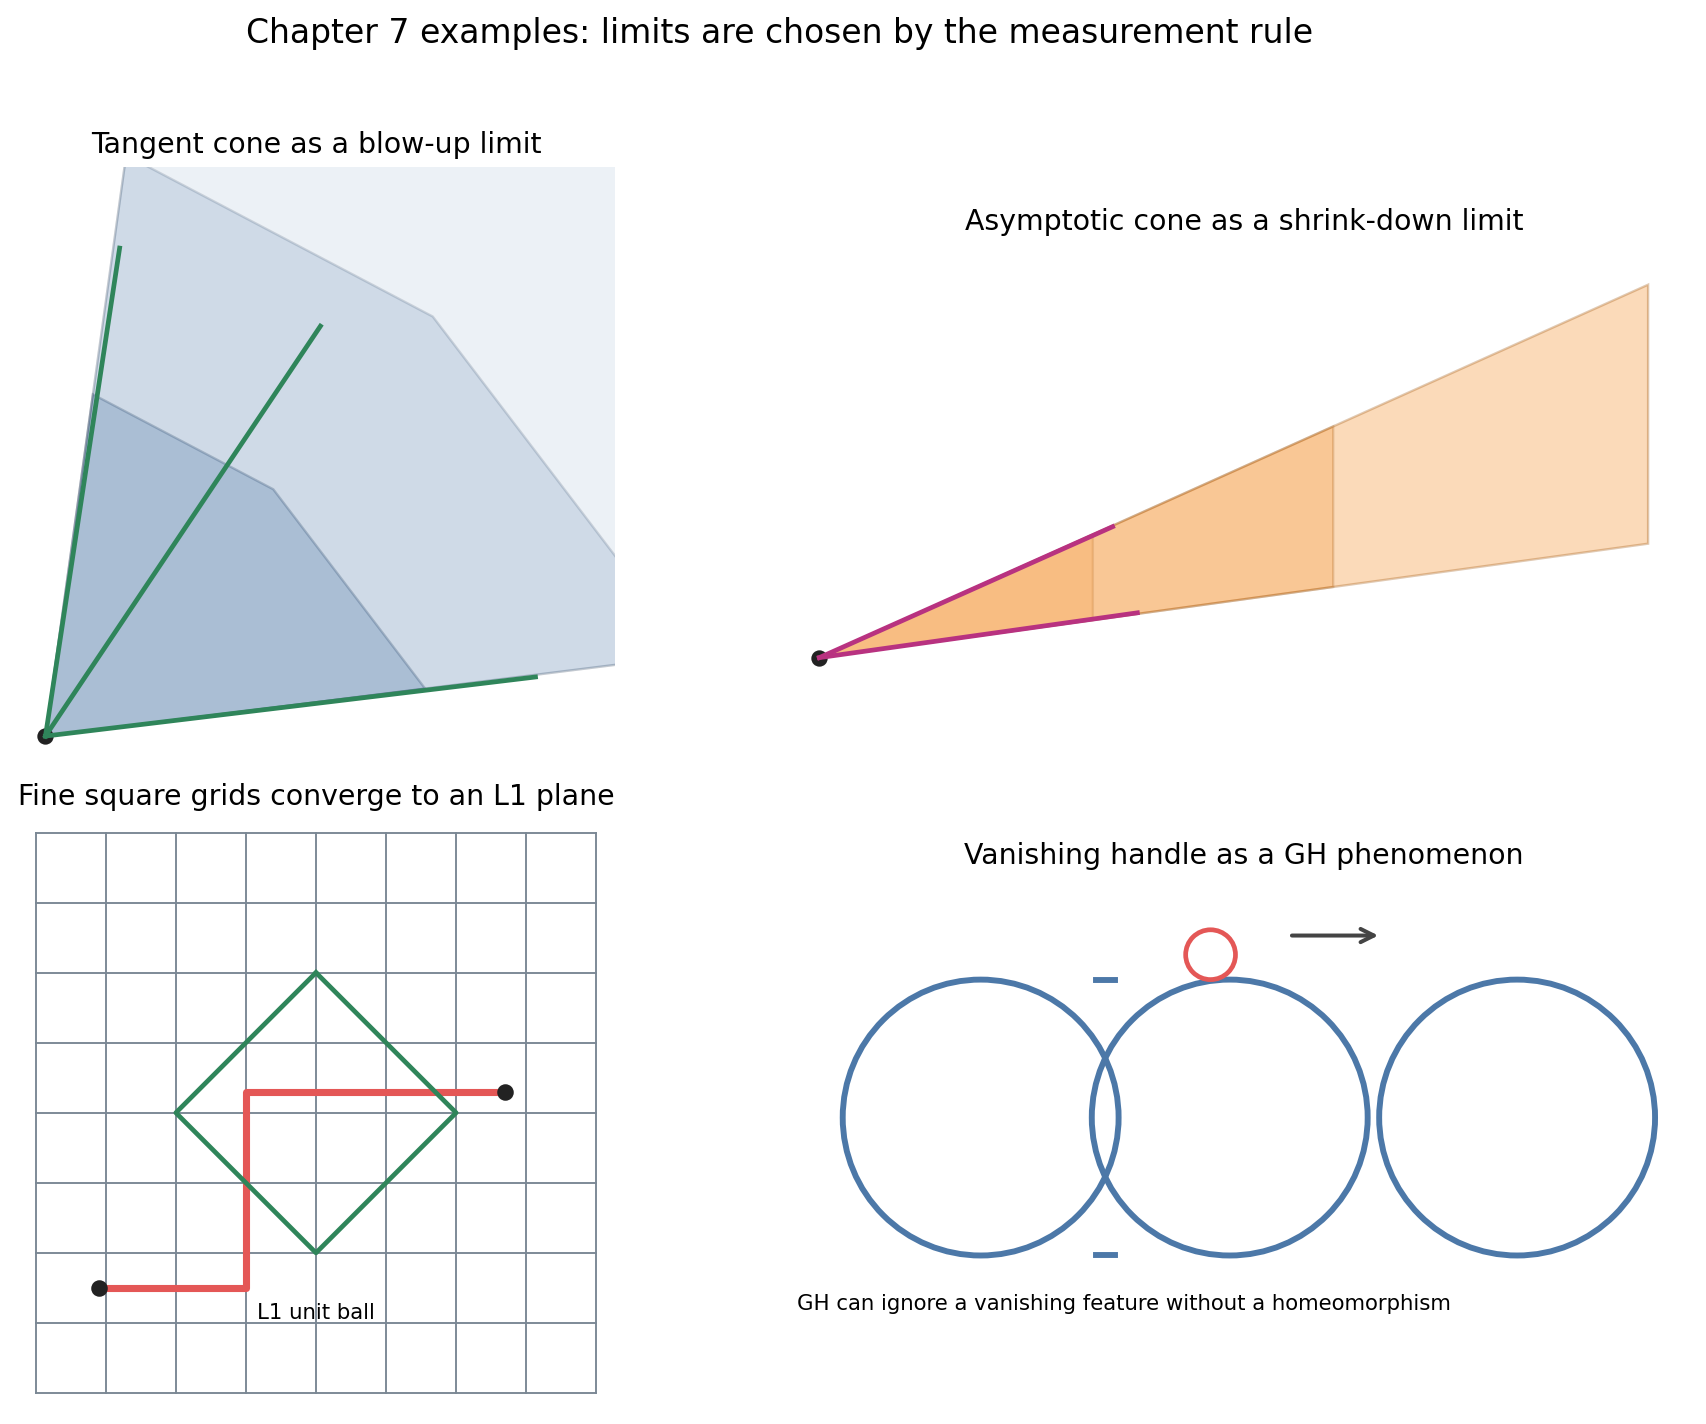

In [3]:
display_artifact(FIG_DIR / 'examples-cones-lattice-handles.png', width=900)


## 7.2 Lipschitz Distance: Relative Error

For a bi-Lipschitz homeomorphism `f : X -> Y`, the Lipschitz distance asks how close both `dil(f)` and `dil(f^{-1})` are to 1. On a finite space of fixed cardinality, a homeomorphism is just a relabeling, so we can compute the best relabeling directly.

This is stricter than additive distortion. Multiplying a tiny distance by 2 can be a small absolute error but a large Lipschitz error. That is why Lipschitz convergence is useful when relative scale matters, and why it cannot compare spaces with different topology or different finite cardinality.


In [4]:
D_triangle = np.array([[0, 1, 1], [1, 0, 1], [1, 1, 0]], dtype=float)
D_stretched = np.array([[0, 1, 1.45], [1, 0, 1.05], [1.45, 1.05, 0]], dtype=float)
eta = 0.16
D_handle = np.array([
    [0, 1, 1, eta],
    [1, 0, 1, 1 + eta],
    [1, 1, 0, 1 + eta],
    [eta, 1 + eta, 1 + eta, 0],
], dtype=float)

for name, matrix in [('triangle', D_triangle), ('stretched triangle', D_stretched), ('triangle plus near-duplicate point', D_handle)]:
    assert is_metric(matrix), name

lip_value, lip_perm = lipschitz_distance_same_cardinality(D_triangle, D_stretched)
uniform_error = map_distortion(D_triangle, D_stretched, lip_perm)
print(f'best labeling for d_L: {lip_perm}')
print(f'Lipschitz distance = {lip_value:.6f}')
print(f'additive distortion for the same labeling = {uniform_error:.6f}')


best labeling for d_L: (0, 1, 2)
Lipschitz distance = 0.371564
additive distortion for the same labeling = 0.450000


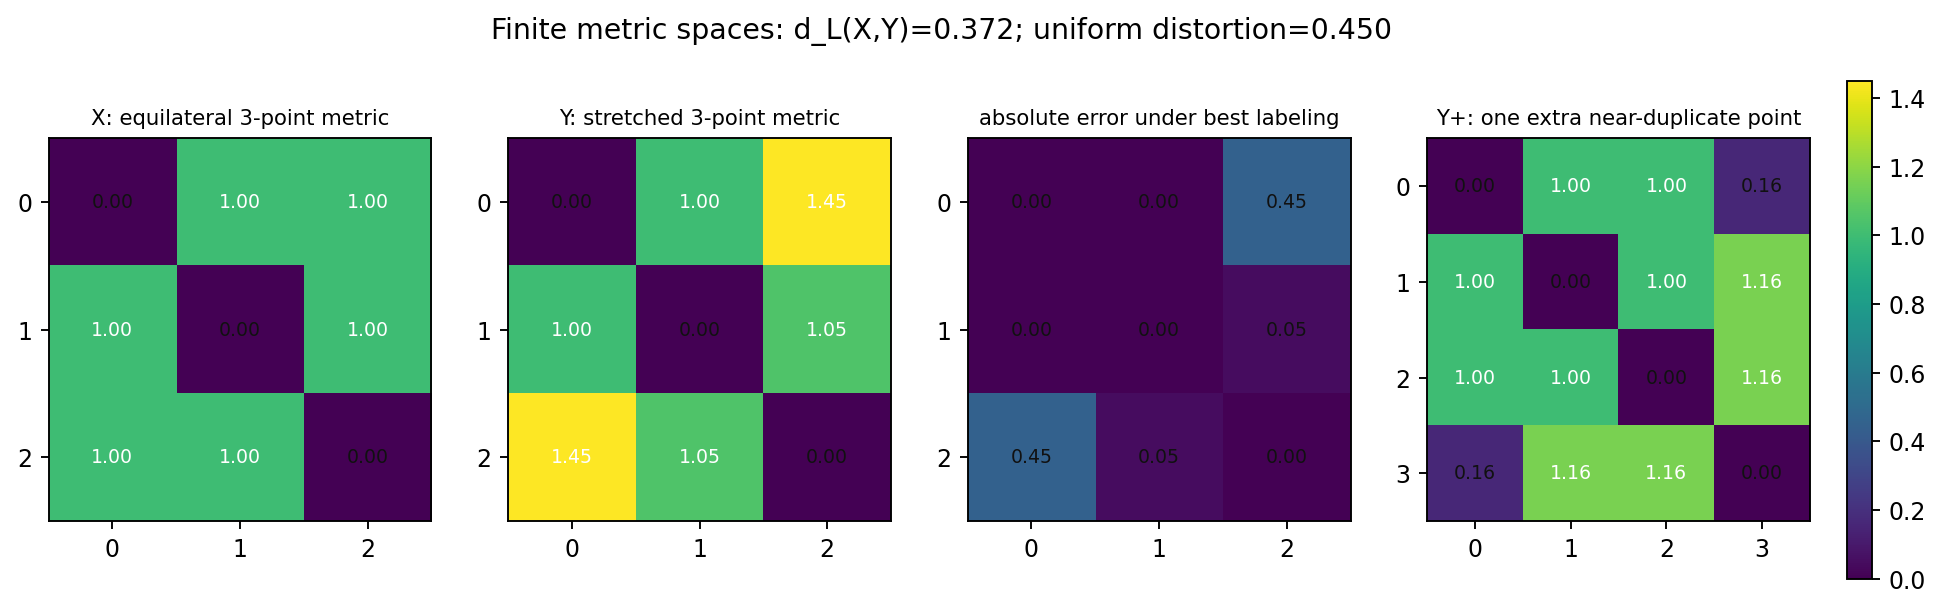

In [5]:
display_artifact(FIG_DIR / 'finite-metric-distance-matrices.png', width=930)


## 7.3 Gromov-Hausdorff Distance: Correspondences Instead of Homeomorphisms

The Hausdorff distance compares subsets already sitting in one ambient metric space. The Gromov-Hausdorff distance removes the ambient space from the input: it asks whether the two spaces can be placed in some common metric space so their Hausdorff distance is small.

The most computable reformulation uses a **correspondence**. A correspondence is a relation `R subset X x Y` in which every point of both spaces appears at least once. Its distortion is the worst distance error among corresponding pairs:

`dis R = sup |d_X(x,x') - d_Y(y,y')|`, for `(x,y), (x',y') in R`.

For compact metric spaces, the chapter proves the formula `d_GH(X,Y) = (1/2) inf_R dis R`.

The finite model below compares a 3-point triangle with a 4-point space obtained by adding one point very close to an old one. A bijection is impossible, but a correspondence can pair the near-duplicate with the same triangle vertex.


In [6]:
gh_upper, best_dis, best_mask = best_correspondence(D_triangle, D_handle)
print(best_mask.astype(int))
print(f'best correspondence distortion = {best_dis:.6f}')
print(f'finite GH value from correspondences = {gh_upper:.6f}')
assert relation_covers(best_mask)
assert gh_upper <= eta + 1e-12


[[1 0 0 1]
 [0 0 1 0]
 [0 1 0 0]]
best correspondence distortion = 0.160000
finite GH value from correspondences = 0.080000


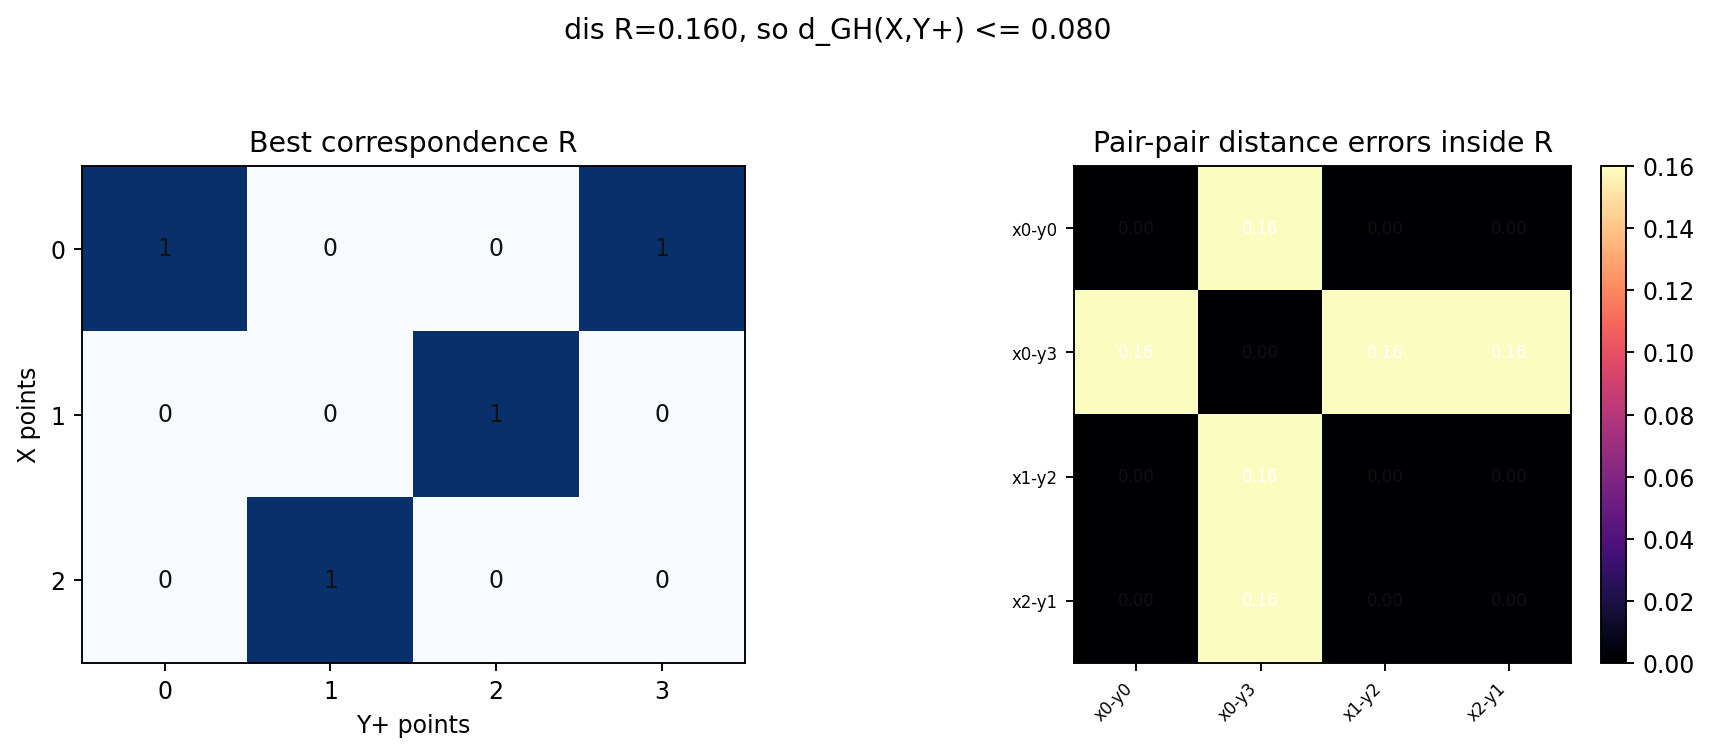

In [7]:
display_artifact(FIG_DIR / 'correspondence-distortion-heatmap.png', width=860)


### Epsilon-Isometries

An `epsilon`-isometry is allowed to be discontinuous. It has two duties: small distortion and an `epsilon`-dense image. This is the right looseness for the vanishing-handle examples: a map may collapse the small handle or choose representatives without respecting topology.

The correspondence picture and the epsilon-isometry picture are equivalent up to constants. That is why the exact value of `d_GH` is often less important than whether the errors can be made arbitrarily small.


## 7.4 Gromov-Hausdorff Convergence Through Finite Nets

Finite spaces are dense in the Gromov-Hausdorff space of compact metric spaces. If `S_n` is an `epsilon_n`-net in a compact space `X` and `epsilon_n -> 0`, then `S_n -> X` in the Gromov-Hausdorff sense.

For the unit circle with intrinsic arc-length distance, `n` equally spaced points have mesh radius at most `pi/n`. The diameter stays `pi`, but the net radius tends to zero. This is the finite approximation principle behind the compactness criterion: control diameters and control the number of points needed for every scale.


In [8]:
ns = np.array([4, 6, 8, 12, 16, 24, 32, 48], dtype=int)
bounds = math.pi / ns
assert np.all(np.diff(bounds) < 0)

rows = []
for n, bound in zip(ns, bounds):
    Dn, _ = circle_distance_matrix(int(n))
    assert is_metric(Dn)
    rows.append({'n': int(n), 'circle_net_gh_upper_bound': float(bound), 'diameter_unit_circle': math.pi})

with (TABLE_DIR / 'circle-net-convergence-bounds.csv').open('w', newline='', encoding='utf-8') as handle:
    writer = csv.DictWriter(handle, fieldnames=['n', 'circle_net_gh_upper_bound', 'diameter_unit_circle'])
    writer.writeheader()
    writer.writerows(rows)

fig, ax = plt.subplots(figsize=(6.5, 3.8))
ax.plot(ns, bounds, marker='o', color='#4C78A8')
ax.set_xlabel('number of equally spaced sample points')
ax.set_ylabel('GH upper bound pi/n')
ax.set_title('Finite-net convergence bound for the unit circle')
ax.grid(True, alpha=0.3)
save_matplotlib(fig, FIG_DIR / 'gh-convergence-finite-nets.png')
plt.close(fig)
print(rows[:3])


[{'n': 4, 'circle_net_gh_upper_bound': 0.7853981633974483, 'diameter_unit_circle': 3.141592653589793}, {'n': 6, 'circle_net_gh_upper_bound': 0.5235987755982988, 'diameter_unit_circle': 3.141592653589793}, {'n': 8, 'circle_net_gh_upper_bound': 0.39269908169872414, 'diameter_unit_circle': 3.141592653589793}]


## Applied Lab: Finite-Net Gromov-Hausdorff Convergence

Use the slider to vary the number of sample points on the circle. The visible task is to compare the shrinking mesh radius with the distance matrix: the entries keep the circle diameter at scale `pi`, while the net radius `pi/n` goes to zero.


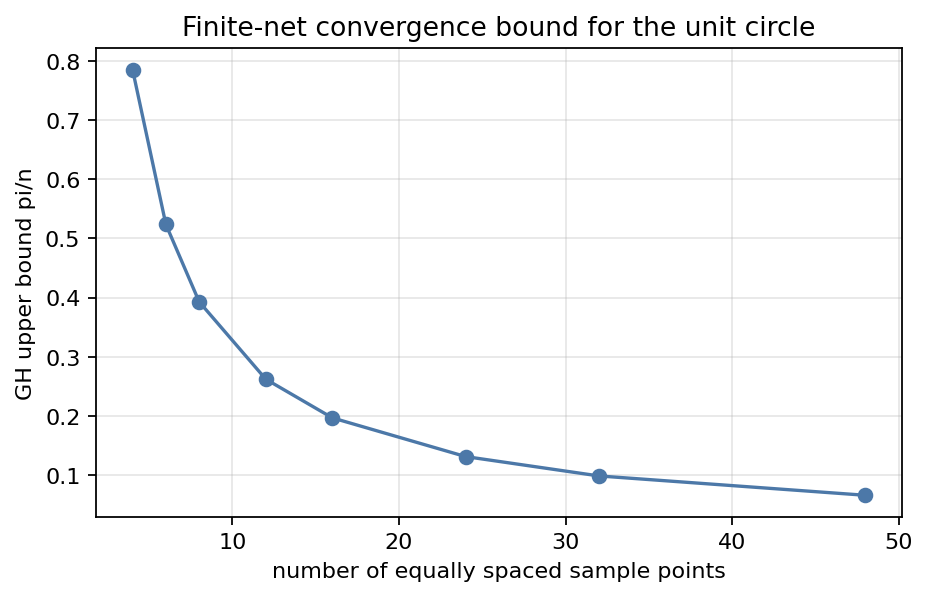

D:\Geometry\.venv\Lib\site-packages\IPython\core\display.py:447: UserWarning: Consider using IPython.display.IFrame instead
  warnings.warn("Consider using IPython.display.IFrame instead")


In [9]:
display_artifact(FIG_DIR / 'gh-convergence-finite-nets.png', width=870)
display_artifact(HTML_DIR / 'gh-convergence-finite-net-lab.html', width=900, height=560)


### Compactness Criterion as a Diagonal Argument

Uniform total boundedness says two things: all spaces in the class have uniformly bounded diameter, and for every scale `epsilon` there is one number `N(epsilon)` that bounds the size of an `epsilon`-net in every space in the class.

The proof strategy is diagonal. Choose compatible nets at scales `1, 1/2, 1/3, ...`. The distance between every named pair of net points lies in a compact interval, so one can pass to subsequences until all these pairwise distances converge. The limiting semi-metric is then quotiented and completed. The finite-net criterion upgrades this finite distance convergence into Gromov-Hausdorff convergence.


## 7.5 Convergence of Length Spaces

The key theorem says that a Gromov-Hausdorff limit of compact length spaces is again a length space, provided the limit is complete. The proof uses the midpoint criterion from Chapter 2.

If `x,y` are points in the limit and `X_n` is close to `X`, choose corresponding points `x_n,y_n` in `X_n`. Since `X_n` is a length space, it has an approximate midpoint `z_n`. Bring `z_n` back across the correspondence. Distortion estimates show that the returned point is an approximate midpoint for `x,y`. Because the error was arbitrary, the limit metric is intrinsic.


In [10]:
def grid_graph_distance(points, eps):
    n = len(points)
    D = np.full((n, n), np.inf)
    np.fill_diagonal(D, 0.0)
    for i, j in itertools.combinations(range(n), 2):
        w = float(np.linalg.norm(points[i] - points[j]))
        if w < eps + 1e-12:
            D[i, j] = D[j, i] = w
    for k in range(n):
        D = np.minimum(D, D[:, [k]] + D[[k], :])
    return D

grid_side = 7
points = np.array([(i/(grid_side-1), j/(grid_side-1)) for i in range(grid_side) for j in range(grid_side)], dtype=float)
eps_graph = 0.34
D_graph = grid_graph_distance(points, eps_graph)
D_euclid = np.linalg.norm(points[:, None, :] - points[None, :, :], axis=2)
residual = D_graph - D_euclid
assert np.isfinite(D_graph).all()
assert np.nanmin(residual) > -1e-9
print(f'max sampled graph excess over Euclidean distance: {float(np.nanmax(residual)):.6f}')


max sampled graph excess over Euclidean distance: 0.089073


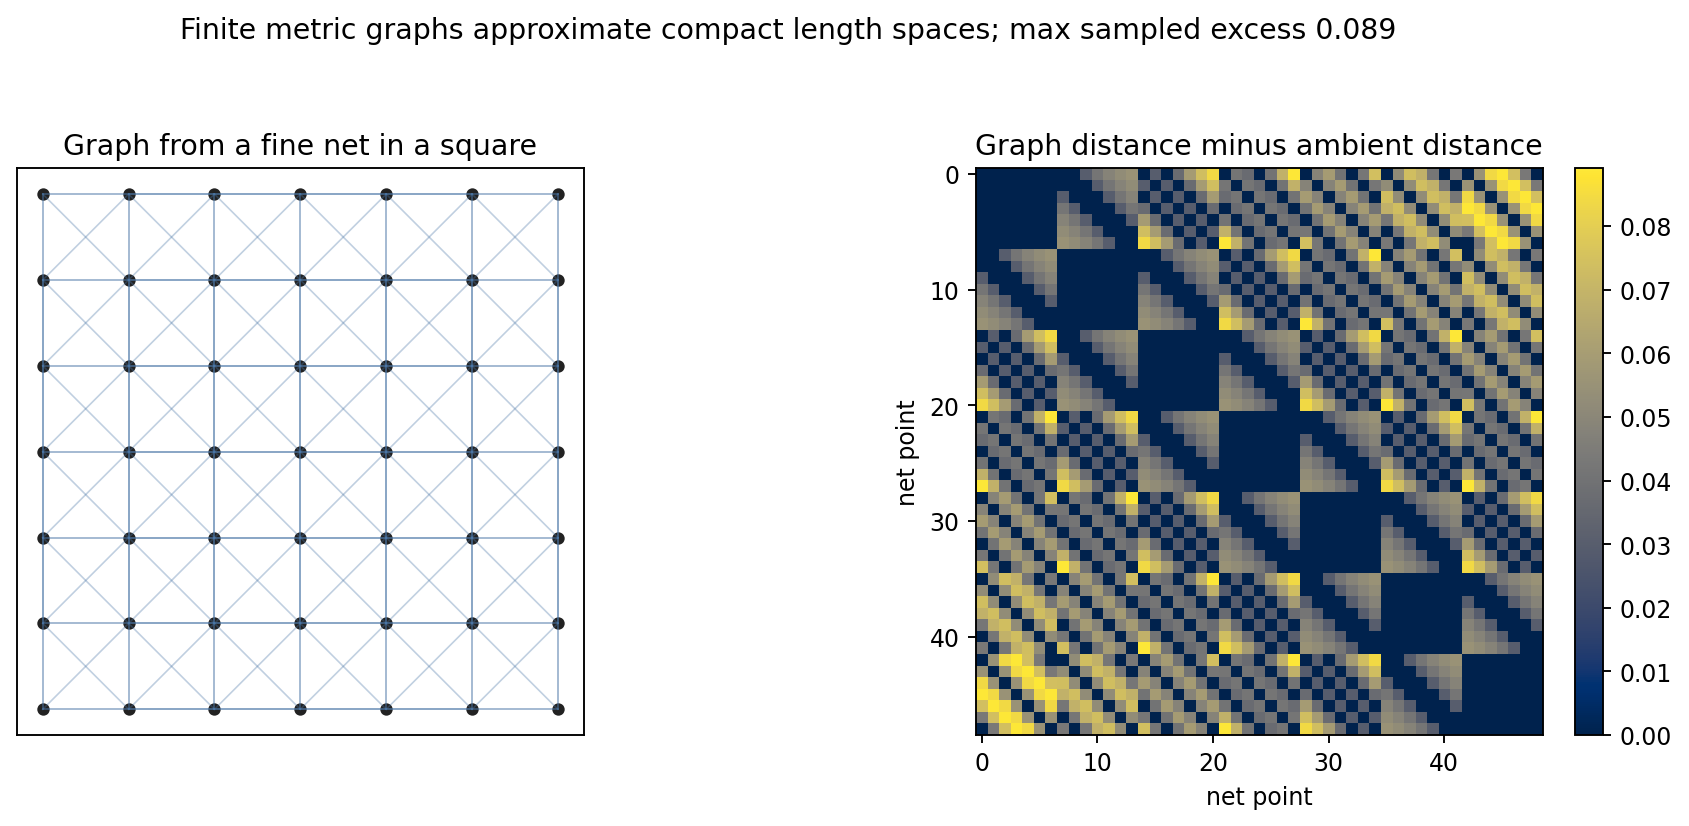

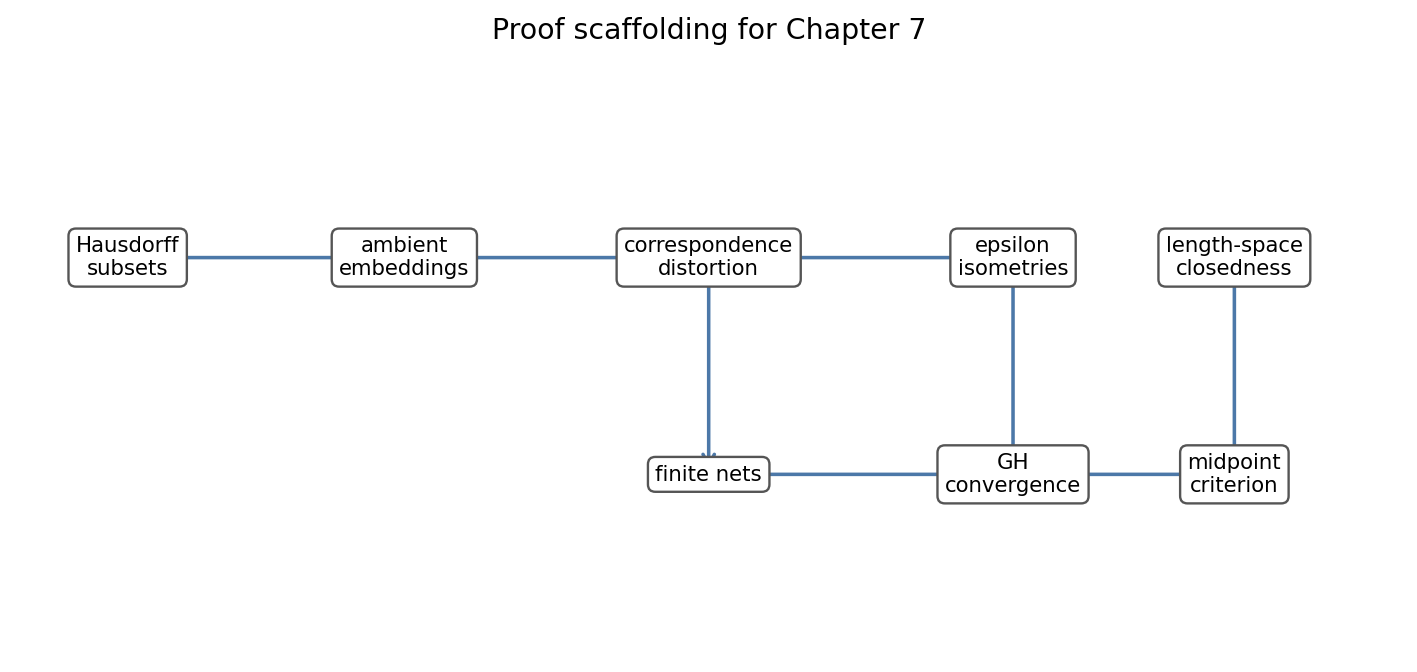

In [11]:
display_artifact(FIG_DIR / 'length-space-graph-approximation.png', width=870)
display_artifact(FIG_DIR / 'proof-flow-gh-to-length-spaces.png', width=870)


## Source Coverage Record

The notebook covers the assigned source span as a teaching path, not as a paraphrase. The JSON artifact below records which sections are represented by which computations and visuals.


In [12]:
source_coverage = {
    'source_span': {'printed_pages': '241-270', 'pdf_pages': '256-285'},
    'sections': [
        {'section': '7.1 Examples', 'covered_by': ['examples-cones-lattice-handles.png', 'motivation prose: cones, lattice, handles, uniform convergence']},
        {'section': '7.2 Lipschitz Distance', 'covered_by': ['finite-metric-distance-matrices.png', 'finite d_L computation and comparison with uniform distortion']},
        {'section': '7.3 Gromov-Hausdorff Distance', 'covered_by': ['correspondence-distortion-heatmap.png', 'correspondence and epsilon-isometry definitions, Hausdorff-to-GH discussion']},
        {'section': '7.4 Gromov-Hausdorff Convergence', 'covered_by': ['gh-convergence-finite-nets.png', 'gh-convergence-finite-net-lab.html', 'finite epsilon-net criterion and precompactness notes']},
        {'section': '7.5 Convergence of Length Spaces', 'covered_by': ['length-space-graph-approximation.png', 'proof-flow-gh-to-length-spaces.png', 'midpoint criterion and graph approximation discussion']},
    ],
    'copyright_note': 'The PDF was used only for terminology, structure, theorem orientation, and coverage. Notebook prose and code are original.',
}
save_json(source_coverage, CHECK_DIR / 'source-coverage.json')
display(source_coverage)


{'source_span': {'printed_pages': '241-270', 'pdf_pages': '256-285'},
 'sections': [{'section': '7.1 Examples',
   'covered_by': ['examples-cones-lattice-handles.png',
    'motivation prose: cones, lattice, handles, uniform convergence']},
  {'section': '7.2 Lipschitz Distance',
   'covered_by': ['finite-metric-distance-matrices.png',
    'finite d_L computation and comparison with uniform distortion']},
  {'section': '7.3 Gromov-Hausdorff Distance',
   'covered_by': ['correspondence-distortion-heatmap.png',
    'correspondence and epsilon-isometry definitions, Hausdorff-to-GH discussion']},
  {'section': '7.4 Gromov-Hausdorff Convergence',
   'covered_by': ['gh-convergence-finite-nets.png',
    'gh-convergence-finite-net-lab.html',
    'finite epsilon-net criterion and precompactness notes']},
  {'section': '7.5 Convergence of Length Spaces',
   'covered_by': ['length-space-graph-approximation.png',
    'proof-flow-gh-to-length-spaces.png',
    'midpoint criterion and graph approximat

## Final Sanity Checks

These checks are intentionally mathematical rather than only file-based. They verify metric axioms, correspondence coverage, convergence monotonicity, graph-distance direction, and artifact integrity.


In [13]:
artifact_paths = [
    FIG_DIR / 'examples-cones-lattice-handles.png',
    FIG_DIR / 'finite-metric-distance-matrices.png',
    FIG_DIR / 'correspondence-distortion-heatmap.png',
    FIG_DIR / 'gh-convergence-finite-nets.png',
    FIG_DIR / 'length-space-graph-approximation.png',
    FIG_DIR / 'proof-flow-gh-to-length-spaces.png',
    HTML_DIR / 'gh-convergence-finite-net-lab.html',
    CHECK_DIR / 'visual-storyboard.json',
    CHECK_DIR / 'source-coverage.json',
    TABLE_DIR / 'circle-net-convergence-bounds.csv',
]
assert_artifacts(artifact_paths, min_bytes=128)

final_sanity = {
    'metrics_are_valid': {
        'triangle': is_metric(D_triangle),
        'stretched_triangle': is_metric(D_stretched),
        'handle_space': is_metric(D_handle),
    },
    'lipschitz_distance_triangle_to_stretched': float(lip_value),
    'best_lipschitz_permutation': list(lip_perm),
    'uniform_distortion_same_labeling': float(uniform_error),
    'best_correspondence_distortion': float(best_dis),
    'best_correspondence_gh_upper_bound': float(gh_upper),
    'best_correspondence_covers_both_spaces': relation_covers(best_mask),
    'circle_net_bounds_strictly_decrease': bool(np.all(np.diff(bounds) < 0)),
    'graph_metric_never_shorter_than_euclidean_samples': bool(np.nanmin(residual) > -1e-9),
    'graph_metric_max_sampled_excess': float(np.nanmax(residual)),
    'source_sections_covered': [item['section'] for item in source_coverage['sections']],
    'artifact_files': [{'path': relative_to_book(path, BOOK_ROOT), 'bytes': path.stat().st_size} for path in artifact_paths],
}
assert all(final_sanity['metrics_are_valid'].values())
assert final_sanity['best_correspondence_covers_both_spaces']
assert len(final_sanity['source_sections_covered']) == 5
save_json(final_sanity, CHECK_DIR / 'final-sanity.json')
final_sanity


{'metrics_are_valid': {'triangle': True,
  'stretched_triangle': True,
  'handle_space': True},
 'lipschitz_distance_triangle_to_stretched': 0.371563556432483,
 'best_lipschitz_permutation': [0, 1, 2],
 'uniform_distortion_same_labeling': 0.44999999999999996,
 'best_correspondence_distortion': 0.16,
 'best_correspondence_gh_upper_bound': 0.08,
 'best_correspondence_covers_both_spaces': True,
 'circle_net_bounds_strictly_decrease': True,
 'graph_metric_never_shorter_than_euclidean_samples': True,
 'graph_metric_max_sampled_excess': 0.08907279243665256,
 'source_sections_covered': ['7.1 Examples',
  '7.2 Lipschitz Distance',
  '7.3 Gromov-Hausdorff Distance',
  '7.4 Gromov-Hausdorff Convergence',
  '7.5 Convergence of Length Spaces'],
 'artifact_files': [{'path': 'artifacts/chapter-07/figures/examples-cones-lattice-handles.png',
   'bytes': 158089},
  {'path': 'artifacts/chapter-07/figures/finite-metric-distance-matrices.png',
   'bytes': 61569},
  {'path': 'artifacts/chapter-07/figures/

## Takeaways

- Lipschitz distance measures relative metric error through bi-Lipschitz homeomorphisms. It is strong and topology-sensitive.
- Gromov-Hausdorff distance measures additive metric error after allowing a common ambient space, a correspondence, or an epsilon-isometry. It is weak enough to compare spaces with different point sets or topology.
- Finite metric spaces are not a toy exception; they are the operational skeleton of compact Gromov-Hausdorff convergence.
- Uniform total boundedness is the compactness mechanism: uniformly many points at every scale allow a diagonal limit of distance matrices.
- Length spaces are closed under complete Gromov-Hausdorff limits because approximate midpoints survive through small-distortion correspondences.
